# KAN-RFB Tutorial — import, data, visualize, train, test

Demonstrates the full pipeline: loading data, plotting bubble shapes,
training both modes (constant & xi) via `train_multi_bubble_on_dataset`,
and testing in the static-condensation assembly.

---
## Colab setup
Run this cell first if using Google Colab (otherwise skip it).

In [1]:
# ── 0. COLAB SETUP (run first if using Colab) ─────────────────────────────
import os, torch
if not os.path.isdir('/content/ML_Galerkin_proj'):
    !git clone https://github.com/juanpaca/ML_Galerkin_proj.git /content/ML_Galerkin_proj
%cd /content/ML_Galerkin_proj
!git pull

print("GPU:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

Cloning into '/content/ML_Galerkin_proj'...
remote: Enumerating objects: 292, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 292 (delta 7), reused 28 (delta 5), pack-reused 258 (from 2)
Receiving objects: 100% (292/292), 142.25 MiB | 44.02 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/content/ML_Galerkin_proj
Already up to date.
GPU: True
Device: Tesla T4


In [2]:
# ── 1. IMPORTS ──────────────────────────────────────────────────────────
import sys, os
# In Colab, CWD is /content; in local, it's the project root
if os.path.isdir('/content/ML_Galerkin_proj'):
    sys.path.insert(0, '/content/ML_Galerkin_proj')
else:
    sys.path.insert(0, '.')

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.dataset_generation import load_dataset, dataset_summary, train_multi_bubble_on_dataset
from src.rfb_bubble import KANBubble1D, MultiKANBubble1D
from src.rfb_exact import ExactRFBubbleSet1D
from src.rfb_assembly import (
    assemble_classical_system, assemble_rfb_condensed_system,
    recover_bubble_coefficients, RFBSolution1D,
)
from src.mesh import Mesh1D
from src.quadrature import GaussLegendre
from src.pde import AdvectionDiffusion1D
from src.basis import LagrangeBasis1D
from src.errors import compute_l2_error, relative_error_percentage

# Move training to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ── 2. LOAD DATASET ─────────────────────────────────────────────────────
ds = load_dataset("rfb_5k")
dataset_summary(ds)

# Dataset structure:
#   ds["train"]["constant"]  →  {pe, rho, xi, b, db}  (797 samples)
#   ds["train"]["xi"]         →  {pe, rho, xi, b, db}
#   ds["val"][...]            →  validation split
#   ds["test"][...]           →  test split

xi_full = ds["train"]["constant"]["xi"]  # original FD grid
print(f"xi grid: {xi_full.shape[0]} points")

Dataset: None
  Samples: 5000 total (4002 train / 499 val / 499 test)
  Strategy: lhs, var_eps_frac: 0.00 (n_eps=0)
  ε ∈ [1.0e-04, 1.0e-01]
  β ∈ [1.0, 1.0]
  σ ∈ [0.0, 10.0]
  Modes: constant, xi
  Split: stratified
    train: Pe ∈ [3.13e-01, 3.12e+02] (median 1.02e+01)
    val: Pe ∈ [3.15e-01, 3.08e+02] (median 8.26e+00)
    test: Pe ∈ [3.16e-01, 3.03e+02] (median 9.34e+00)
xi grid: 400 points


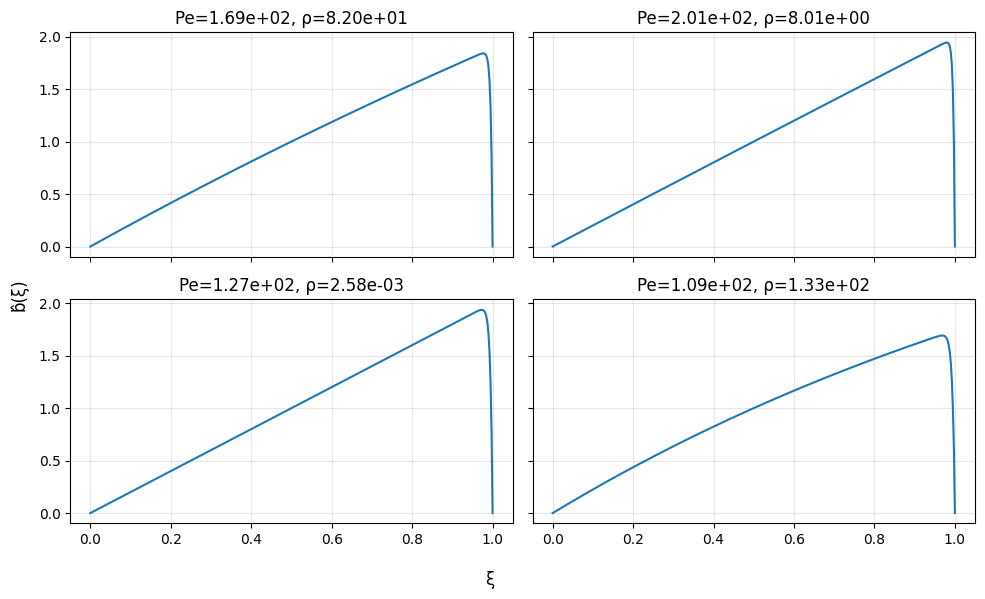

Left: low Pe (diffusion-dominated)  →  rounded, symmetric
Right: high Pe (advection-dominated) →  sharp boundary layer at ξ=1


In [4]:
# ── 3. VISUALIZE BUBBLE SHAPES IN THE DATASET ────────────────────────────
mode = "constant"
train_data = ds["train"][mode]
idx = [0, 100, 200, 300]

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
for ax, i in zip(axes.flat, idx):
    ax.plot(xi_full, train_data["b"][i])
    ax.set_title(f"Pe={train_data['pe'][i]:.2e}, ρ={train_data['rho'][i]:.2e}")
    ax.grid(True, alpha=0.3)
fig.supxlabel("ξ")
fig.supylabel("b̂(ξ)")
fig.tight_layout()
plt.show()

print("Left: low Pe (diffusion-dominated)  →  rounded, symmetric")
print("Right: high Pe (advection-dominated) →  sharp boundary layer at ξ=1")

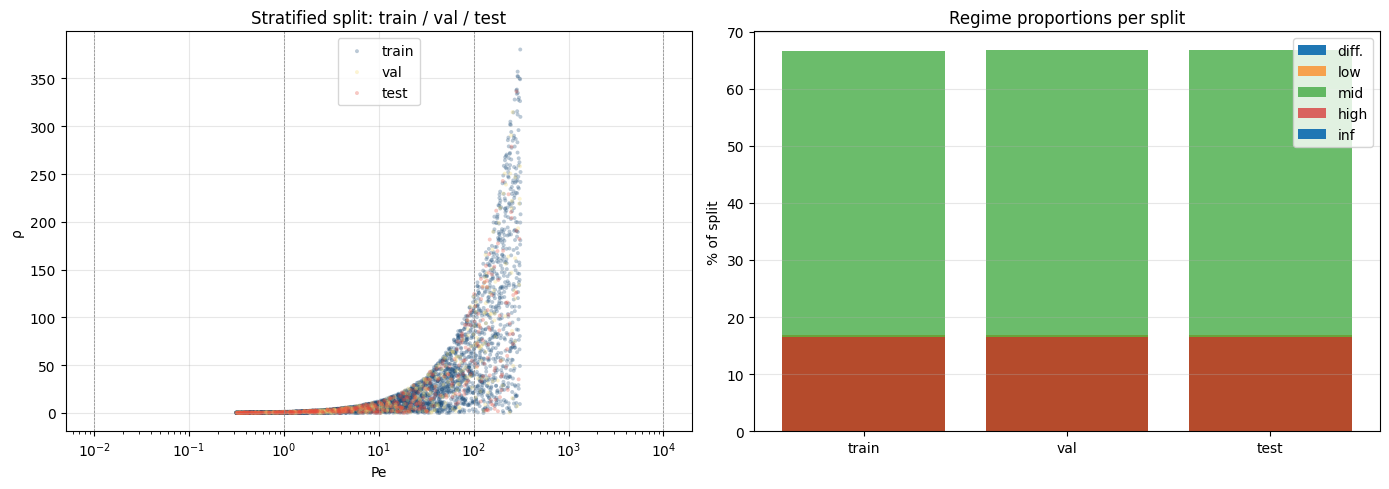

Samples: 4002 train / 499 val / 499 test
Overlap train∩val: 0
Overlap train∩test: 0
Overlap val∩test: 0
→ No leakage

train:
   diff.:     0 (  0.0%)
     low:   674 ( 16.8%)
     mid:  2667 ( 66.6%)
    high:   661 ( 16.5%)
     inf:     0 (  0.0%)

val:
   diff.:     0 (  0.0%)
     low:    84 ( 16.8%)
     mid:   333 ( 66.7%)
    high:    82 ( 16.4%)
     inf:     0 (  0.0%)

test:
   diff.:     0 (  0.0%)
     low:    84 ( 16.8%)
     mid:   333 ( 66.7%)
    high:    82 ( 16.4%)
     inf:     0 (  0.0%)


In [5]:
# ── VISUALIZE STRATIFIED SPLIT & CHECK NO LEAKAGE ──
# Pe regimes used by the stratified split
regime_edges = [0.01, 1.0, 100.0, 1e4]
regime_labels = ["diff.", "low", "mid", "high", "inf"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"train": "#1F4E79", "val": "#F7DC6F", "test": "#E74C3C"}

# Left: Pe vs ρ scatter
for sname in ["train", "val", "test"]:
    pe_s = ds[sname]["constant"]["pe"]
    rho_s = ds[sname]["constant"]["rho"]
    axes[0].scatter(pe_s, rho_s, c=colors[sname], alpha=0.3, s=8, label=sname, edgecolors='none')
axes[0].set_xscale("log")
axes[0].set_xlabel("Pe")
axes[0].set_ylabel("ρ")
axes[0].set_title("Stratified split: train / val / test")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for e in regime_edges:
    axes[0].axvline(e, color="gray", lw=0.5, ls="--")

# Right: regime proportion bar chart
def regime_counts(pe_vals):
    counts = {}
    for pe in pe_vals:
        if pe > 1e4:
            r = "inf"
        elif pe > 100:
            r = "high"
        elif pe > 1:
            r = "mid"
        elif pe > 0.01:
            r = "low"
        else:
            r = "diff."
        counts[r] = counts.get(r, 0) + 1
    return counts

import pandas as pd
rows = []
for sname in ["train", "val", "test"]:
    rc = regime_counts(ds[sname]["constant"]["pe"])
    total = sum(rc.values())
    for regime, cnt in rc.items():
        rows.append({"split": sname, "regime": regime, "pct": cnt/total*100})
df = pd.DataFrame(rows)
for reg in regime_labels:
    sub = df[df.regime == reg]
    axes[1].bar(sub.split, sub.pct, label=reg, alpha=0.7)
axes[1].set_ylabel("% of split")
axes[1].set_title("Regime proportions per split")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Verify: no sample overlap between splits
train_ids = set(ds["metadata"]["split_indices"]["train"])
val_ids   = set(ds["metadata"]["split_indices"]["val"])
test_ids  = set(ds["metadata"]["split_indices"]["test"])
print(f"Samples: {len(train_ids)} train / {len(val_ids)} val / {len(test_ids)} test")
print(f"Overlap train∩val: {len(train_ids & val_ids)}")
print(f"Overlap train∩test: {len(train_ids & test_ids)}")
print(f"Overlap val∩test: {len(val_ids & test_ids)}")
print("→ No leakage" if not (train_ids & val_ids or train_ids & test_ids or val_ids & test_ids) else "→ LEAKAGE DETECTED!")

# Print regime counts per split
for sname in ["train", "val", "test"]:
    rc = regime_counts(ds[sname]["constant"]["pe"])
    total = sum(rc.values())
    print(f"\n{sname}:")
    for reg in regime_labels:
        cnt = rc.get(reg, 0)
        print(f"  {reg:>6s}: {cnt:5d} ({cnt/total*100:5.1f}%)")

In [6]:
# ── 5. TRAINING (both modes) ────────────────────────────────────────────
# Uses the built-in train_multi_bubble_on_dataset which trains each
# bubble independently with value-only loss (grad_weight=0).

multi_model = MultiKANBubble1D(n_bubbles=2, n_hidden=10, n_grid=8, spline_order=3)
n_params = sum(p.numel() for p in multi_model.parameters())
print(f"MultiKANBubble1D: {n_params} params ({n_params // 2} per mode)\n")

multi_model.to(device)

print(f"CUDA: {torch.cuda.is_available()}, device: {next(multi_model.parameters()).device}")
print(f"Train samples: {len(ds['train']['constant']['pe'])}")


MultiKANBubble1D: 960 params (480 per mode)

CUDA: True, device: cuda:0
Train samples: 4002


In [ ]:
# ── Single-forward benchmark ──

import time, torch
model = multi_model.bubbles[0]
xi = torch.linspace(0, 1, 100, device=device)
pe = torch.full_like(xi, 10.0)
rho = torch.full_like(xi, 0.0)

# warmup
for _ in range(5): model(xi, pe, rho); torch.cuda.synchronize()

# timed
t0 = time.time()
for _ in range(50): model(xi, pe, rho); torch.cuda.synchronize()
t1 = time.time()
print(f"Single forward (100 pts): {(t1-t0)/50*1000:.1f} ms  |  {(t1-t0)/50:.4f} s")
# Expected: < 1 ms on GPU. If >5 ms, there's a kernel-launch overhead issue.


# ── Full batch benchmark (256 samples, 100 pts each) ──
BS = 256; Q = 100
xi_b = torch.linspace(0, 1, Q, device=device).unsqueeze(0).expand(BS, -1).reshape(-1)
pe_b = torch.full((BS*Q,), 10.0, device=device)
rho_b = torch.full((BS*Q,), 0.0, device=device)

# warmup
for _ in range(3): multi_model(xi_b, pe_b, rho_b); torch.cuda.synchronize()

t0 = time.time()
for _ in range(20): multi_model(xi_b, pe_b, rho_b); torch.cuda.synchronize()
t1 = time.time()
fwd_time = (t1-t0)/20
print(f"Batch forward (256×100 pts): {fwd_time*1000:.1f} ms  |  {fwd_time:.4f} s")

# fwd+bwd (loss-less, no grad term)
opt = torch.optim.Adam(multi_model.parameters(), lr=1e-3)
t0 = time.time()
for _ in range(10):
    opt.zero_grad()
    out = multi_model(xi_b, pe_b, rho_b)
    loss = out.mean()
    loss.backward()
    opt.step()
    torch.cuda.synchronize()
t1 = time.time()
step_time = (t1-t0)/10
print(f"Batch step (fwd+bwd+opt, 256×100): {step_time*1000:.1f} ms  |  {step_time:.4f} s")
print(f"Estimated for 700 epochs × 4 batches/epoch: {700*4*step_time/60:.0f} min")
# Expected: step < 20 ms → ~1 min total

Single forward (100 pts): 3.2 ms  |  0.0032 s
Batch forward (256×100 pts): 10.1 ms  |  0.0101 s
Batch step (fwd+bwd+opt, 256×100): 25.9 ms  |  0.0259 s
Estimated for 700 epochs × 4 batches/epoch: 1 min


In [7]:
histories = train_multi_bubble_on_dataset(
    multi_model, ds["train"],
    mode_names=("constant", "xi"),
    n_epochs=700, batch_size=256, lr=1e-3,
    grad_weight=0.1,   # value-only — gradient term diverges
    n_quad=100,
    verbose=True,
    device=device,
)
print("\nTraining done!")

Training mode 'constant' (1/2)
  epoch 70/700: loss=1.798518e-02
  epoch 140/700: loss=7.241263e-03
  epoch 210/700: loss=3.923028e-03
  epoch 280/700: loss=2.564866e-03
  epoch 350/700: loss=1.763815e-03
  epoch 420/700: loss=1.597311e-03
  epoch 490/700: loss=1.259047e-03
  epoch 560/700: loss=1.006940e-03
  epoch 630/700: loss=1.023544e-03
  epoch 700/700: loss=8.558241e-04
Training mode 'xi' (2/2)
  epoch 70/700: loss=4.829681e-02
  epoch 140/700: loss=2.389957e-02
  epoch 210/700: loss=1.851215e-02
  epoch 280/700: loss=1.462961e-02
  epoch 350/700: loss=1.204824e-02
  epoch 420/700: loss=1.029004e-02
  epoch 490/700: loss=7.756792e-03
  epoch 560/700: loss=1.223450e-02
  epoch 630/700: loss=8.027968e-03
  epoch 700/700: loss=6.475044e-03

Training done!


In [8]:
# ── 5B. SAVE OR LOAD PRETRAINED MODEL (use if training interrupted) ────────────────
from google.colab import files
#torch.save(multi_model.state_dict(), "models/multi_kan_400ep.pt")
file_name = "multi_kan_700ep_5k.pt"
torch.save(multi_model.state_dict(), file_name)

# 2. Automatically trigger your web browser to download it
files.download(file_name)

# Replace multi_model with the pre-trained one
# multi_model = MultiKANBubble1D(n_bubbles=2, n_hidden=5, n_grid=8, spline_order=3)
# multi_model.load_state_dict(torch.load('models/multi_bubble_model_1k.pt'))
# print("Loaded pretrained model from models/multi_bubble_model_1k.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

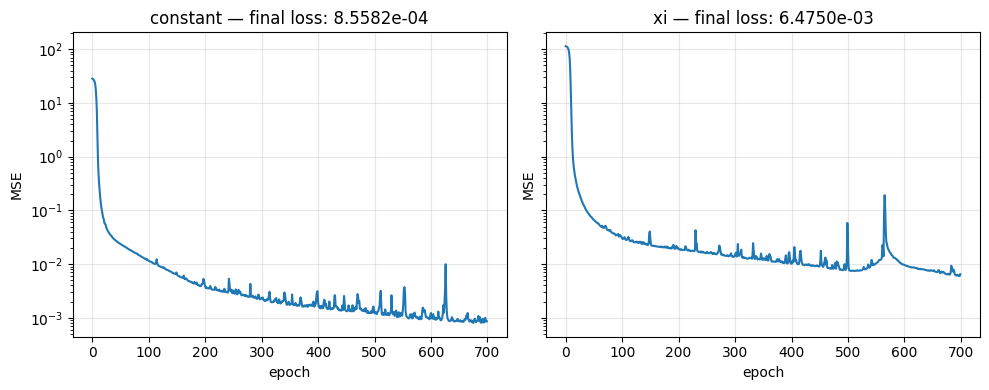

In [9]:
# ── 5C. LOSS CURVES (only if training was run) ─────────────────────────────
if 'histories' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for ax, (mname, hist) in zip(axes, histories.items()):
        ax.plot(hist)
        ax.set_yscale('log')
        ax.set_xlabel('epoch')
        ax.set_ylabel('MSE')
        ax.set_title(f"{mname} — final loss: {hist[-1]:.4e}")
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("Training not run — skipping loss curves.")

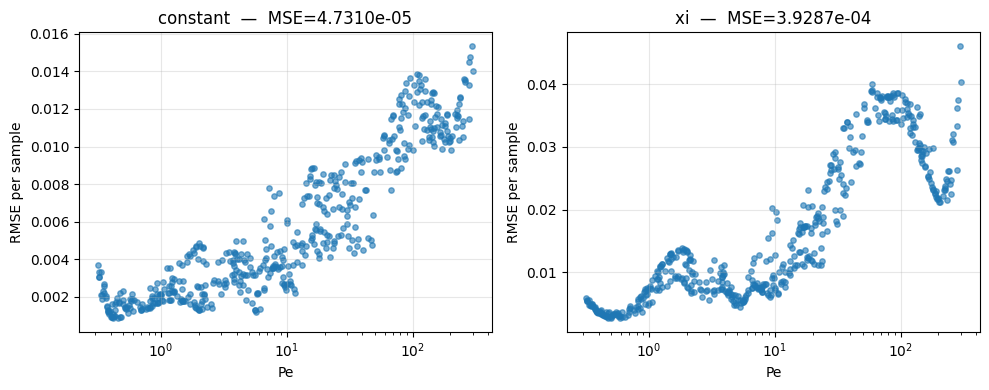

In [10]:
# ── 5D. TEST BOTH MODES ON THE HELD-OUT TEST SET ────────────────────────
xi_full_t = torch.tensor(xi_full, dtype=torch.float32, device=device)
n_fd = len(xi_full)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (i, mname) in enumerate([(0, "constant"), (1, "xi")]):
    test_data = ds["test"][mname]
    p_te = torch.tensor(test_data["pe"], dtype=torch.float32, device=device)
    r_te = torch.tensor(test_data["rho"], dtype=torch.float32, device=device)
    n_te = p_te.shape[0]

    with torch.no_grad():
        xi_et = xi_full_t.unsqueeze(0).expand(n_te, -1).reshape(-1)
        p_et  = p_te.unsqueeze(1).expand(-1, n_fd).reshape(-1)
        r_et  = r_te.unsqueeze(1).expand(-1, n_fd).reshape(-1)
        pred = multi_model.bubbles[i](xi_et, p_et, r_et).reshape(n_te, n_fd)
        mse = F.mse_loss(pred, torch.tensor(test_data["b"], dtype=torch.float32, device=device)).item()
        rms = np.sqrt(np.mean((pred.cpu().numpy() - test_data["b"])**2, axis=1))

    axes[ax].scatter(test_data["pe"], rms, alpha=0.6, s=15)
    axes[ax].set_xscale('log')
    axes[ax].set_xlabel('Pe')
    axes[ax].set_ylabel('RMSE per sample')
    axes[ax].set_title(f"{mname}  —  MSE={mse:.4e}")
    axes[ax].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

IndexError: index 4 is out of bounds for axis 0 with size 4

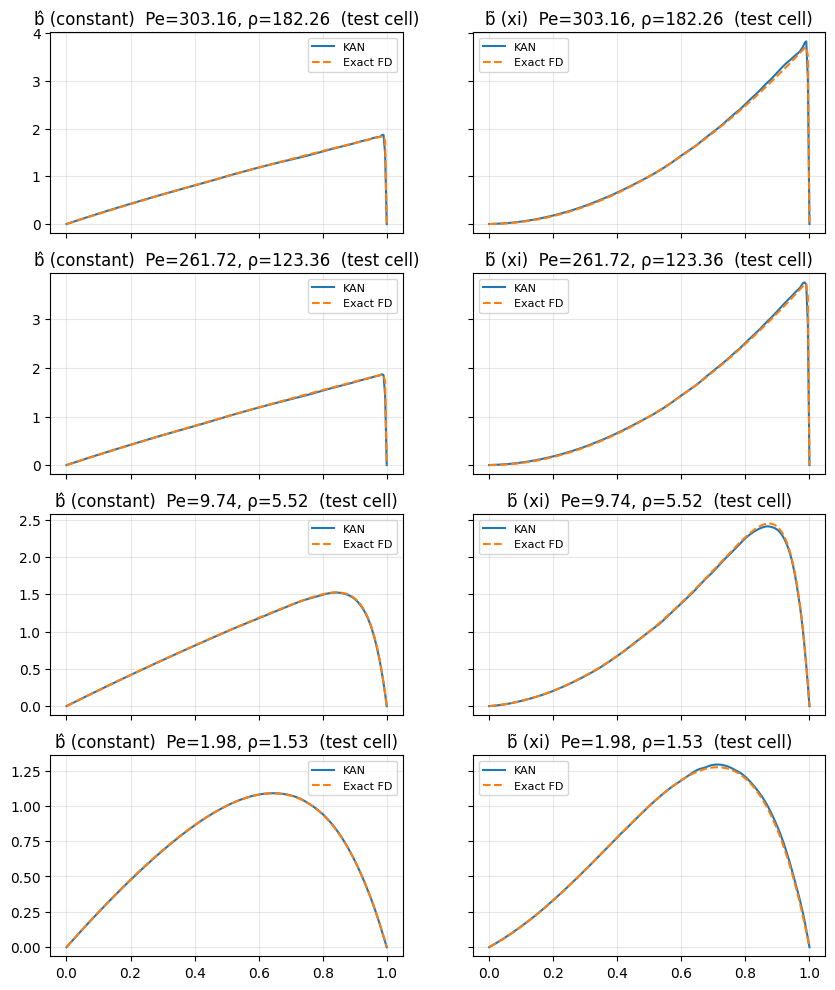

In [12]:
# ── 6. COMPARE BUBBLE SHAPES: KAN vs EXACT ──────────────────────────────
# Uses actual samples from the HELD-OUT test set (cell-based split).
# The model has never seen these (Pe, ρ) regimes during training.

xi_plot = np.linspace(0, 1, 201)
H = 1/16; BETA = 1.0

# Pick 4 samples from the test set, spread across the test Pe-ρ range
test_data_const = ds["test"]["constant"]
test_idx = [0, 10, 200, 300, 400]
pe_samples = test_data_const["pe"][test_idx]
rho_samples = test_data_const["rho"][test_idx]

fig, axes = plt.subplots(4, 2, figsize=(10, 12), sharex=True, sharey='row')
for row, (pe, rho) in enumerate(zip(pe_samples, rho_samples)):
    eps = BETA * H / (2 * pe) if pe > 0 else 1.0
    sigma = rho * eps / H**2

    b_kan, _ = multi_model.value_grad_numpy(xi_plot, pe, rho)

    exact = ExactRFBubbleSet1D(eps, BETA, sigma, H,
                                residual_modes=("constant", "xi"), n_points=4000)
    b_ex, _ = exact.value_grad_numpy(xi_plot, pe, rho)

    for col, (mode_name, k, e) in enumerate([("b̂ (constant)", 0, 0), ("b̃ (xi)", 1, 1)]):
        axes[row, col].plot(xi_plot, b_kan[k], label='KAN')
        axes[row, col].plot(xi_plot, b_ex[e], '--', label='Exact FD')
        axes[row, col].set_title(f"{mode_name}  Pe={pe:.2f}, ρ={rho:.2f}  (test cell)")
        axes[row, col].legend(fontsize=8)
        axes[row, col].grid(True, alpha=0.3)

fig.supxlabel('ξ')
fig.tight_layout()
plt.show()


In [13]:
# ── 7. ASSEMBLY: classical vs KAN-RFB vs exact RFB ──────────────────────
# Uses a PDE configuration from the HELD-OUT test set.
# The KAN model has never seen this (Pe, ρ) during training.

# Take the first test sample's parameters
pe_test = ds["test"]["constant"]["pe"][490]  # ≈ 1.5
rho_test = ds["test"]["constant"]["rho"][490]  # ≈ 0.5
H = 1/16; BETA = 1.0
EPS = BETA * H / (2 * pe_test)  # ε such that Pe matches test cell
SIGMA = rho_test * EPS / H**2
N_EL = 16

print(f"Test case: ε={EPS:.4f}, β={BETA}, σ={SIGMA:.4f}")
print(f"  Pe={BETA*H/(2*EPS):.2f}, ρ={SIGMA*H**2/EPS:.2f}  (from test cell)")

mesh = Mesh1D(0.0, 1.0, N_EL)
quad = GaussLegendre(16)
pde = AdvectionDiffusion1D(EPS, BETA, SIGMA)
pde.set_source_from_function(lambda x: np.ones_like(x))

# ── Ground truth (fine FD) ──
N_FD = 8000
dx_ref = 1.0 / (N_FD - 1)
x_ref = np.linspace(0, 1, N_FD)
A_ref = np.zeros((N_FD, N_FD))
rhs_ref = np.ones(N_FD)
for i in range(1, N_FD - 1):
    A_ref[i, i-1] = -EPS/dx_ref**2 - BETA/(2*dx_ref)
    A_ref[i, i]   =  2*EPS/dx_ref**2 + SIGMA
    A_ref[i, i+1] = -EPS/dx_ref**2 + BETA/(2*dx_ref)
A_ref[0,0] = A_ref[-1,-1] = 1.0
rhs_ref[0] = rhs_ref[-1] = 0.0
u_exact = np.linalg.solve(A_ref, rhs_ref)

def exact_u(x): return np.interp(x, x_ref, u_exact)

# ── 1. Classical P1 ──
A_cl, F_cl = assemble_classical_system(mesh, quad, pde)
u_cl = np.linalg.solve(A_cl, F_cl)

class ClassicalSolution:
    def __init__(self, mesh, u):
        self.mesh = mesh; self.u = u
    def __call__(self, x):
        basis = LagrangeBasis1D(self.mesh)
        out = np.zeros_like(x)
        for i in range(self.mesh.n_nodes):
            out += self.u[i] * basis.eval(x, i)
        return out

l2_cl, norm = compute_l2_error(ClassicalSolution(mesh, u_cl), exact_u)
print(f"\nClassical P1:  L2 = {l2_cl:.4e}  ({relative_error_percentage(l2_cl, norm):.1f}%)")

# ── 2. Exact RFB ──
exact_set = ExactRFBubbleSet1D(EPS, BETA, SIGMA, mesh.h,
                                residual_modes=("constant", "xi"), n_points=8000)
A_ex, F_ex, local_ex = assemble_rfb_condensed_system(mesh, quad, pde, exact_set)
u_ex = np.linalg.solve(A_ex, F_ex)
ub_ex = recover_bubble_coefficients(u_ex, mesh, local_ex)
sol_ex = RFBSolution1D(u_ex, ub_ex, mesh, exact_set, pde)
l2_ex, _ = compute_l2_error(sol_ex, exact_u)
print(f"Exact RFB:     L2 = {l2_ex:.4e}  ({relative_error_percentage(l2_ex, norm):.1f}%)")

# ── 3. KAN-RFB (trained both modes) ──
A_kan, F_kan, local_kan = assemble_rfb_condensed_system(mesh, quad, pde, multi_model)
u_kan = np.linalg.solve(A_kan, F_kan)
ub_kan = recover_bubble_coefficients(u_kan, mesh, local_kan)
sol_kan = RFBSolution1D(u_kan, ub_kan, mesh, multi_model, pde)
l2_kan, _ = compute_l2_error(sol_kan, exact_u)
print(f"KAN-RFB:       L2 = {l2_kan:.4e}  ({relative_error_percentage(l2_kan, norm):.1f}%)")

print(f"\n{'Method':<20} {'L2 error':<12} {'Rel %':<8}")
print(f"{'-'*20} {'-'*12} {'-'*8}")
for name, err in [("Classical P1", l2_cl), ("Exact RFB", l2_ex), ("KAN-RFB", l2_kan)]:
    print(f"{name:<20} {err:<12.4e} {relative_error_percentage(err, norm):<8.1f}")


Test case: ε=0.0041, β=1.0, σ=0.5909
  Pe=7.56, ρ=0.56  (from test cell)

Classical P1:  L2 = 1.4125e-01  (30.2%)
Exact RFB:     L2 = 4.6165e-03  (1.0%)
KAN-RFB:       L2 = 4.7353e-03  (1.0%)

Method               L2 error     Rel %   
-------------------- ------------ --------
Classical P1         1.4125e-01   30.2    
Exact RFB            4.6165e-03   1.0     
KAN-RFB              4.7353e-03   1.0     


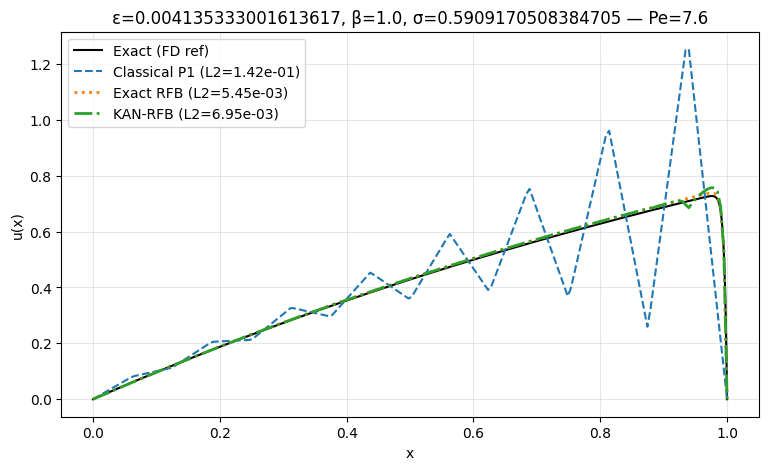

In [ ]:
# ── 8. PLOT SOLUTIONS ───────────────────────────────────────────────────
x_p = np.linspace(0, 1, 200)
plt.figure(figsize=(9, 5))
plt.plot(x_ref, u_exact, 'k-', lw=1.5, label='Exact (FD ref)')
plt.plot(x_p, ClassicalSolution(mesh, u_cl)(x_p), '--', label=f'Classical P1 (L2={l2_cl:.2e})')
plt.plot(x_p, sol_ex(x_p), ':', lw=2, label=f'Exact RFB (L2={l2_ex:.2e})')
plt.plot(x_p, sol_kan(x_p), '-.', lw=2, label=f'KAN-RFB (L2={l2_kan:.2e})')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.title(f'ε={EPS}, β={BETA}, σ={SIGMA} — Pe={BETA*mesh.h/(2*EPS):.1f}')
plt.grid(True, alpha=0.3)
plt.show()